# 1. 데이터 로드 및 구조 확인

In [1]:
import seaborn as sns
import pandas as pd

# 데이터 로드
iris = sns.load_dataset('iris')

# 구조 확인
print("--- 데이터 상단 5행 ---")
print(iris.head())
print("\n--- 데이터 요약 정보 ---")
print(iris.info())

--- 데이터 상단 5행 ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- 데이터 요약 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


# 2. 기술통계량 확인

In [2]:
# Species별 Petal Length의 기술통계량 출력
desc_stats = iris.groupby('species')['petal_length'].describe()
print("--- Species별 Petal Length 기술통계량 ---")
print(desc_stats)

# 그룹별 데이터 개수 확인
group_counts = iris['species'].value_counts()
print("\n--- 그룹별 데이터 개수 ---")
print(group_counts)

--- Species별 Petal Length 기술통계량 ---
            count   mean       std  min  25%   50%    75%  max
species                                                       
setosa       50.0  1.462  0.173664  1.0  1.4  1.50  1.575  1.9
versicolor   50.0  4.260  0.469911  3.0  4.0  4.35  4.600  5.1
virginica    50.0  5.552  0.551895  4.5  5.1  5.55  5.875  6.9

--- 그룹별 데이터 개수 ---
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# 3. 시각화

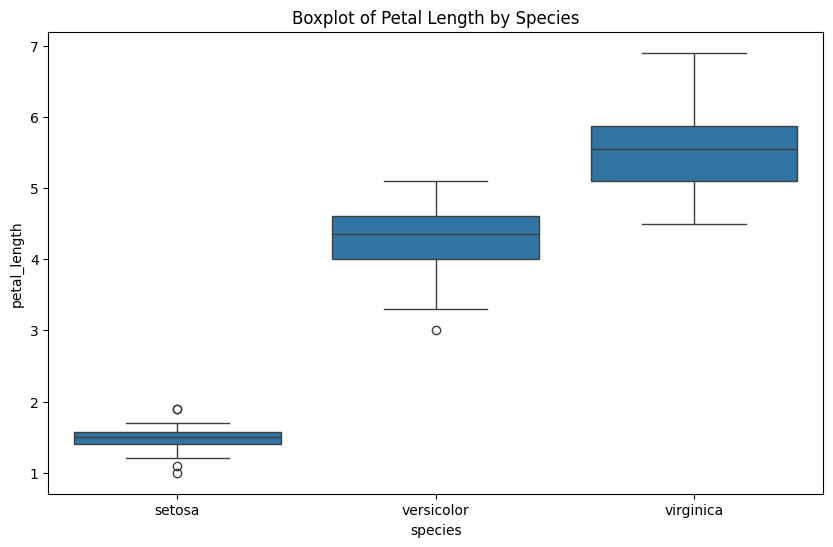

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal_length', data=iris) # [cite: 24]
plt.title('Boxplot of Petal Length by Species')
plt.show()

- Setosa의 Petal Length가 가장 짧으며 데이터의 변동성이 매우 작다.

- Virginica 종이 가장 긴 Petal Length를 가지며 Versicolor는 그 중간에 위치한다.

- 세 그룹 간의 중앙값 차이가 뚜렷하게 나타나므로 통계적으로 유의미한 차이가 있을 것으로 예상된다.

# 4. 정규성 검정
귀무가설($H_0$): 해당 종의 Petal Length 데이터는 정규분포를 따른다.
대립가설 ($H_1$): 해당 종의 Petal Length 데이터는 정규분포를 따르지 않는다.

In [4]:
from scipy import stats

print("--- Shapiro-Wilk 정규성 검정 결과 ---")
for species in iris['species'].unique():
    data = iris[iris['species'] == species]['petal_length']
    statistic, p_value = stats.shapiro(data)

    print(f"[{species}]")
    print(f"p-value: {p_value:.4f}")

    # 0.05 기준으로 해석
    if p_value > 0.05:
        print("결과: 유의수준 0.05에서 귀무가설을 채택하므로 정규성을 만족한다.")
    else:
        print("결과: 유의수준 0.05에서 귀무가설을 기각하므로 정규성을 만족하지 않는다.")
    print("-" * 30)

--- Shapiro-Wilk 정규성 검정 결과 ---
[setosa]
p-value: 0.0548
결과: 유의수준 0.05에서 귀무가설을 채택하므로 정규성을 만족한다.
------------------------------
[versicolor]
p-value: 0.1585
결과: 유의수준 0.05에서 귀무가설을 채택하므로 정규성을 만족한다.
------------------------------
[virginica]
p-value: 0.1098
결과: 유의수준 0.05에서 귀무가설을 채택하므로 정규성을 만족한다.
------------------------------


# 5. 등분산성 검정(Levene)

In [5]:
# 종별 Petal Length 데이터 분리
setosa_pl = iris[iris['species'] == 'setosa']['petal_length']
versicolor_pl = iris[iris['species'] == 'versicolor']['petal_length']
virginica_pl = iris[iris['species'] == 'virginica']['petal_length']

# Levene 검정 수행
levene_stat, levene_p = stats.levene(setosa_pl, versicolor_pl, virginica_pl)

print("--- Levene 등분산성 검정 결과 ---")
print(f"Statistic: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")

# 0.05 기준으로 해석
if levene_p > 0.05:
    print("결과: 유의수준 0.05에서 귀무가설을 채택하므로 등분산성을 만족한다.")
else:
    print("결과: 유의수준 0.05에서 귀무가설을 기각하므로 등분산성을 만족하지 않는다.")

# 과제 지침에 따라 이후 분석은 등분산성을 만족한다고 가정했습니다!

--- Levene 등분산성 검정 결과 ---
Statistic: 19.4803
p-value: 0.0000
결과: 유의수준 0.05에서 귀무가설을 기각하므로 등분산성을 만족하지 않는다.


# 6. ANOVA 가설 수립
귀무가설($H_0$): 세 가지 species 간의 Petal Length 평균은 모두 같다.
대립가설($H_1$): 적어도 한 species의 Petal Length 평균은 나머지 종들과 다르다.

# 7. One-way ANOVA

In [6]:
# One-way ANOVA!!
f_stat, anova_p = stats.f_oneway(setosa_pl, versicolor_pl, virginica_pl)

print("--- One-way ANOVA 결과 ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {anova_p:.10e}") # 매우 작은 값일 수 있음을 고려해 과학적 표기사용

# 유의수준 0.05 기준 귀무가설 기각 여부 판단
if anova_p < 0.05:
    print("결과: 유의수준 0.05에서 귀무가설을 기각한다.")
    print("해석: 세 종 간의 Petal Length 평균에는 통계적으로 유의미한 차이가 존재한다.")
else:
    print("결과: 유의수준 0.05에서 귀무가설을 채택한다.")
    print("해석: 세 종 간의 Petal Length 평균에는 통계적으로 유의미한 차이가 없다.")

--- One-way ANOVA 결과 ---
F-statistic: 1180.1612
p-value: 2.8567766110e-91
결과: 유의수준 0.05에서 귀무가설을 기각한다.
해석: 세 종 간의 Petal Length 평균에는 통계적으로 유의미한 차이가 존재한다.


# 8. 사후검정(Tukey HSD)

In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD 사후검정 수행
tukey = pairwise_tukeyhsd(endog=iris['petal_length'],
                          groups=iris['species'],
                          alpha=0.05)

print("--- Tukey HSD 사후검정 결과 ---")
print(tukey)

--- Tukey HSD 사후검정 결과 ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor    2.798   0.0 2.5942 3.0018   True
    setosa  virginica     4.09   0.0 3.8862 4.2938   True
versicolor  virginica    1.292   0.0 1.0882 1.4958   True
---------------------------------------------------------


# 9. 결과 요약
- 분석 결과: ANOVA 검정 결과 p-value가 유의수준 0.05보다 훨씬 작아 종별로 Petal Length의 평균 차이가 있음이 입증되었다.

- 종별 특징: Setosa 종의 Petal Length가 통계적으로 가장 짧으며 Virginica 종이 가장 길다.

- 결론: 세 종은 Petal Length 측면에서 서로 확연히 구분되는 특성을 가지며 모든 종 간의 차이는 통계적으로 유의미하다.

# 10. 회귀 분석
sepal_length, sepal_width, petal_width를 독립 변수로 사용하여 petal_length를 예측하는 선형 회귀 모델 구축해보기!

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 준비(입력 변수와 타겟 변수 설정)
X = iris[['sepal_length', 'sepal_width', 'petal_width']]
y = iris['petal_length']

# 2. Train/Test 데이터 분리(8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Linear Regression 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 예측 및 평가 지표 출력
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- 회귀 분석 결과 ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# 5. 회귀 계수 확인
print("\n--- 회귀 계수 (Coefficients) ---")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef:.4f}")
print(f"Intercept (절편): {model.intercept_:.4f}")

--- 회귀 분석 결과 ---
Mean Squared Error (MSE): 0.1300
R-squared (R²): 0.9603

--- 회귀 계수 (Coefficients) ---
sepal_length: 0.7228
sepal_width: -0.6358
petal_width: 1.4675
Intercept (절편): -0.2622
